In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('/kaggle/input/datasets/anurananbharadwaj/nn-from-scratch-mnist/train.csv')

In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data = np.array(data) #dataframe to array to do math operations

In [5]:
# To avoid overfitting

m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
x_dev = data_dev[1:n] / 255.0

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0

In [6]:
def init_params():
    W1 = np.random.rand(10, 784) * 0.01
    b1 = np.random.rand(10, 1)

    W2 = np.random.rand(10, 10) * 0.01
    b2 = np.random.rand(10, 1)

    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

#def softmax(Z):
    #return np.exp(Z) / np.sum(np.exp(Z))
def softmax(Z):
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)  # prevents overflow
    return np.exp(Z_stable) / np.sum(np.exp(Z_stable), axis=0, keepdims=True)
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z):
    return Z > 0
    
def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [7]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size
    
def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if(i % 10 == 0):
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [8]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration:  0
[3 3 3 ... 3 3 3] [1 3 1 ... 1 7 4]
Accuracy:  0.10380487804878048
Iteration:  10
[3 3 3 ... 3 3 3] [1 3 1 ... 1 7 4]
Accuracy:  0.13253658536585367
Iteration:  20
[3 0 3 ... 3 3 0] [1 3 1 ... 1 7 4]
Accuracy:  0.11763414634146341
Iteration:  30
[3 0 3 ... 3 0 9] [1 3 1 ... 1 7 4]
Accuracy:  0.14590243902439023
Iteration:  40
[3 0 3 ... 3 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.234390243902439
Iteration:  50
[3 0 3 ... 7 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.25553658536585366
Iteration:  60
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.32826829268292684
Iteration:  70
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.3421707317073171
Iteration:  80
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.3734878048780488
Iteration:  90
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.42504878048780487
Iteration:  100
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.47109756097560973
Iteration:  110
[1 0 1 ... 1 7 4] [1 3 1 ... 1 7 4]
Accuracy:  0.5233414634146342
Iteration:  120
[1 3

In [9]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [0]
Label:  7


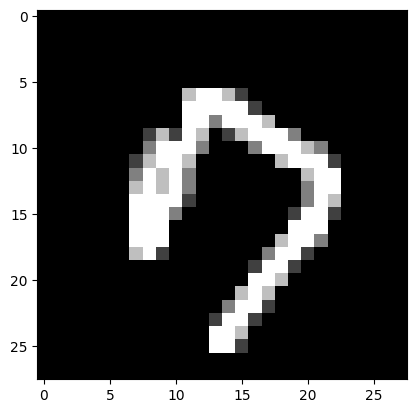

In [10]:
test_prediction(8, W1, b1, W2, b2)